In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class AddNoise:
    def __init__(self, sigma=0.05): self.sigma = sigma
    def __call__(self, x): return (x + self.sigma * torch.randn_like(x)).clamp(0, 1)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.GaussianBlur(3, sigma=(0.1, 1.0)),
    AddNoise(0.05),
])
transform_test = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.CIFAR10("./data", train=True,  download=True, transform=transform_train)
test_ds  = datasets.CIFAR10("./data", train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=0)

classes = train_ds.classes

In [4]:
def spike(x):
    return (x > 0).float() + (x - x.detach()) / (1 + (torch.pi * x).abs()) ** 2

class LIF(nn.Module):
    def __init__(self, T=8, beta=0.5, thr=1.0):
        super().__init__()
        self.T, self.beta, self.thr = T, beta, thr
    def forward(self, x):
        mem = torch.zeros_like(x); out = 0
        for _ in range(self.T):
            mem = self.beta * mem + x
            s = spike(mem - self.thr)
            mem = mem - self.thr * s
            out = out + s
        return out / self.T

In [5]:
class SNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  64,  3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1, bias=False)
        self.bn3   = nn.BatchNorm2d(256)
        self.lif1, self.lif2, self.lif3 = LIF(T=8), LIF(T=8), LIF(T=8)
        self.drop  = nn.Dropout(0.3)
        self.fc    = nn.Linear(256 * 4 * 4, 10)

    def forward(self, x):
        x = self.lif1(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)
        x = self.lif2(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)
        x = self.lif3(self.bn3(self.conv3(x)))
        x = F.max_pool2d(x, 2)
        x = self.drop(x.flatten(1))
        return self.fc(x)


In [6]:
def fgsm(m, x, y, eps=8/255):
    xa = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(m(xa), y)
    return (xa + eps * torch.autograd.grad(loss, xa)[0].sign()).clamp(0, 1).detach()

def pgd(m, x, y, eps=8/255, alpha=2/255, steps=7):
    xa = (x + torch.empty_like(x).uniform_(-eps, eps)).clamp(0, 1).detach()
    for _ in range(steps):
        xa.requires_grad_(True)
        loss = F.cross_entropy(m(xa), y)
        g = torch.autograd.grad(loss, xa)[0]
        xa = (xa + alpha * g.sign()).detach()
        xa = (x + (xa - x).clamp(-eps, eps)).clamp(0, 1)
    return xa.detach()

In [7]:
def noise(x, s=0.1):  
    return (x + s * torch.randn_like(x)).clamp(0, 1)
    
def shift(x):         
    return torch.roll(x, (3, 3), (2, 3))
    
def blur(x):
    k = torch.ones(3, 1, 3, 3, device=x.device) / 9
    return F.conv2d(x, k, padding=1, groups=3)
    
def rotate(x, a=15):
    t = torch.tensor([[np.cos(np.radians(a)), -np.sin(np.radians(a)), 0],
                      [np.sin(np.radians(a)),  np.cos(np.radians(a)), 0]],
                     dtype=torch.float, device=x.device).unsqueeze(0)
    g = F.affine_grid(t.expand(x.size(0), -1, -1), x.size(), align_corners=False)
    return F.grid_sample(x, g, align_corners=False).clamp(0, 1)

In [8]:
def mixup(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

In [9]:
def train_epoch(m, loader, opt, robust=True):
    m.train()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        xm, ya, yb, lam = mixup(x, y)

        if robust:
            r = np.random.rand()
            if r < 0.35:
                xa = pgd(m, x, y, eps=8/255, steps=5)
            elif r < 0.55:
                xa = fgsm(m, x, y, eps=8/255)
            elif r < 0.75:
                xa = noise(x, 0.1)
            else:
                xa = rotate(x, 15)
            opt.zero_grad()
            out_c = m(xm)
            out_a = m(xa)
            loss = lam * F.cross_entropy(out_c, ya) + (1 - lam) * F.cross_entropy(out_c, yb)
            loss = loss + F.cross_entropy(out_a, y)
        else:
            opt.zero_grad()
            out = m(xm)
            loss = lam * F.cross_entropy(out, ya) + (1 - lam) * F.cross_entropy(out, yb)

        loss.backward(); opt.step()

@torch.no_grad()
def evaluate(m, loader):
    m.eval(); P, Y = [], []
    for x, y in loader:
        P.append(m(x.to(device)).argmax(1).cpu()); Y.append(y)
    P, Y = torch.cat(P).numpy(), torch.cat(Y).numpy()
    return (P == Y).mean(), f1_score(Y, P, average="macro"), P, Y

In [10]:
def robustness(m, loader):
    res = {}
    for name, fn in [("clean",  lambda x, y: x),
                     ("noise",  lambda x, y: noise(x)),
                     ("shift",  lambda x, y: shift(x)),
                     ("blur",   lambda x, y: blur(x)),
                     ("rotate", lambda x, y: rotate(x)),
                     ("fgsm",   lambda x, y: fgsm(m, x, y)),
                     ("pgd",    lambda x, y: pgd(m, x, y, steps=10))]:
        P, Y = [], []
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with torch.enable_grad() if name in ("fgsm", "pgd") else torch.no_grad():
                P.append(m(fn(x, y)).argmax(1).cpu()); Y.append(y.cpu())
        P, Y = torch.cat(P).numpy(), torch.cat(Y).numpy()
        res[name] = (P == Y).mean()
    return res

In [11]:
def plot_cm(P, Y, title):
    cm = confusion_matrix(Y, P)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(title); plt.xlabel("pred"); plt.ylabel("true")
    plt.tight_layout(); plt.show()

In [12]:
def gradcam(m, img, cls=None):
    acts, grads = {}, {}
    h1 = m.conv3.register_forward_hook(lambda mod, i, o: acts.__setitem__("a", o))
    h2 = m.conv3.register_full_backward_hook(lambda mod, gi, go: grads.__setitem__("g", go[0]))
    m.eval()
    x = img.unsqueeze(0).to(device)
    out = m(x)
    cls = cls if cls is not None else out.argmax(1).item()
    m.zero_grad(); out[0, cls].backward()
    h1.remove(); h2.remove()
    w = grads["g"].mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * acts["a"]).sum(1, keepdim=True))
    cam = F.interpolate(cam, (32, 32), mode="bilinear", align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() + 1e-8), cls

In [13]:
def show_attention(m, ds, n=3):
    fig, ax = plt.subplots(2, n, figsize=(3*n, 6))
    for i in range(n):
        img, y = ds[i]
        cam, pred = gradcam(m, img)
        ax[0, i].imshow(img.permute(1, 2, 0)); ax[0, i].set_title(classes[y]); ax[0, i].axis("off")
        ax[1, i].imshow(img.permute(1, 2, 0)); ax[1, i].imshow(cam, cmap="jet", alpha=.5)
        ax[1, i].set_title(f"pred: {classes[pred]}"); ax[1, i].axis("off")
    plt.suptitle("Матрица внимания"); plt.tight_layout(); plt.show()

  epoch  1: acc=0.528  macroF1=0.514
  epoch  2: acc=0.566  macroF1=0.550
  epoch  3: acc=0.597  macroF1=0.592
  epoch  4: acc=0.638  macroF1=0.627
  epoch  5: acc=0.687  macroF1=0.681
  epoch  6: acc=0.695  macroF1=0.684
  epoch  7: acc=0.675  macroF1=0.670
  epoch  8: acc=0.666  macroF1=0.655
  epoch  9: acc=0.715  macroF1=0.714
  epoch 10: acc=0.746  macroF1=0.746


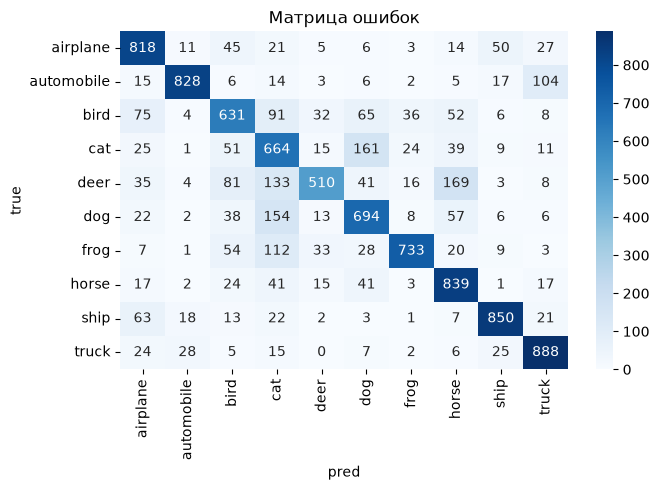

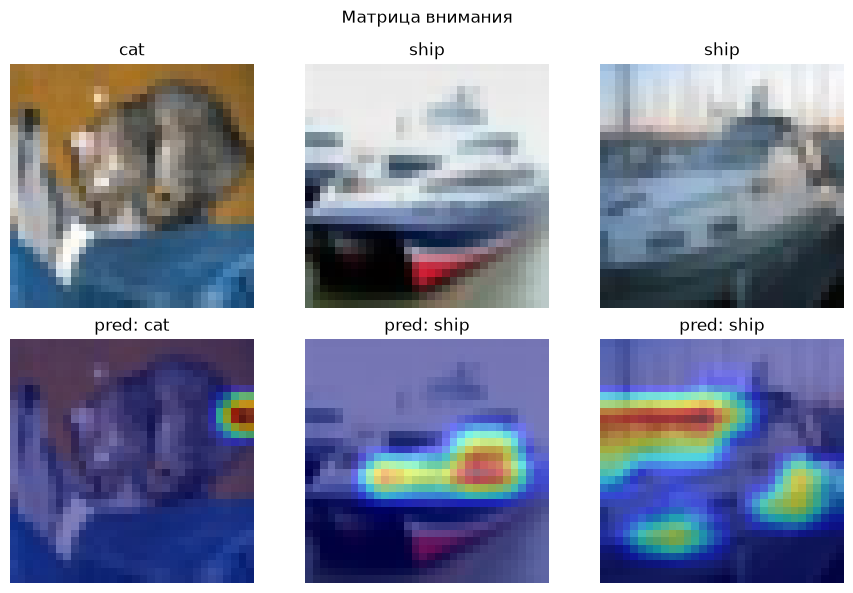

In [14]:
model = SNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)

for ep in range(10):
    train_epoch(model, train_loader, opt, robust=False)
    sched.step()
    acc, f1, _, _ = evaluate(model, test_loader)
    print(f"  epoch {ep+1:2d}: acc={acc:.3f}  macroF1={f1:.3f}")

acc, f1, P, Y = evaluate(model, test_loader)
plot_cm(P, Y, "Матрица ошибок")
show_attention(model, test_ds)
rb = robustness(model, test_loader)

  epoch  1: acc=0.711  macroF1=0.707
  epoch  2: acc=0.703  macroF1=0.696
  epoch  3: acc=0.720  macroF1=0.715
  epoch  4: acc=0.716  macroF1=0.711
  epoch  5: acc=0.717  macroF1=0.710
  epoch  6: acc=0.727  macroF1=0.722
  epoch  7: acc=0.727  macroF1=0.721
  epoch  8: acc=0.729  macroF1=0.723
  epoch  9: acc=0.727  macroF1=0.720
  epoch 10: acc=0.730  macroF1=0.723


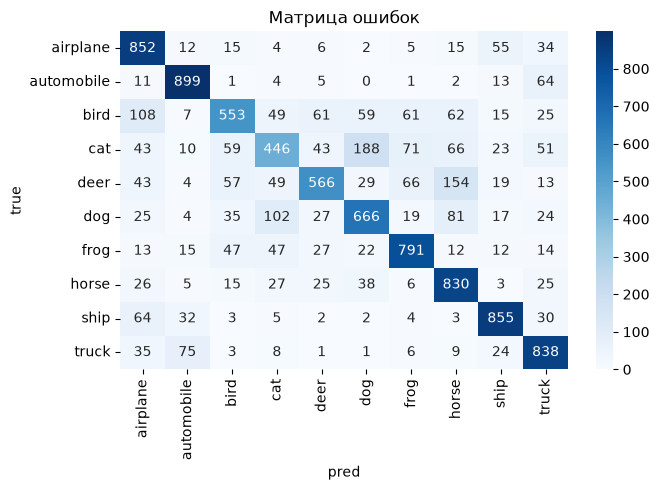

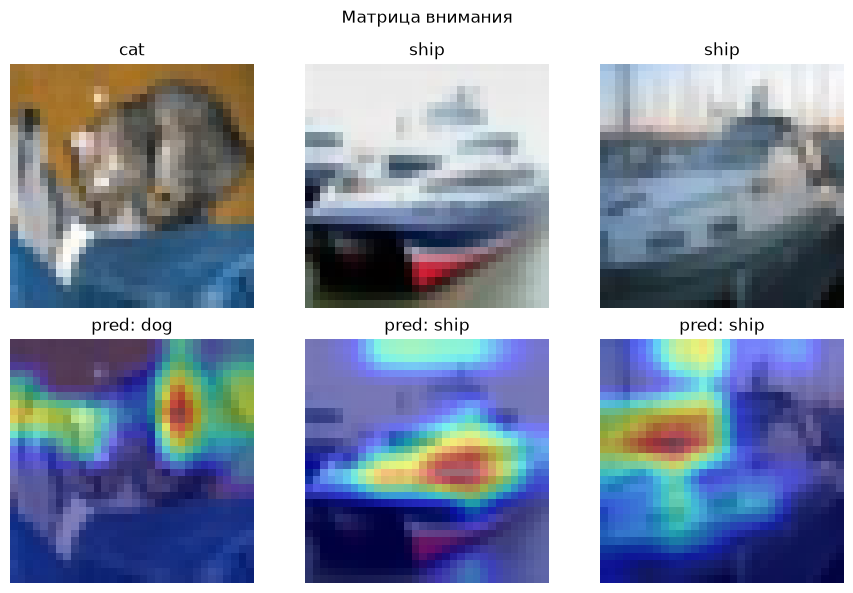

In [15]:
opt = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=5e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10)
for ep in range(10):
    train_epoch(model, train_loader, opt, robust=True)
    sched.step()
    acc, f1, _, _ = evaluate(model, test_loader)
    print(f"  epoch {ep+1:2d}: acc={acc:.3f}  macroF1={f1:.3f}")

acc, f1, P, Y = evaluate(model, test_loader)
plot_cm(P, Y, "Матрица ошибок")
show_attention(model, test_ds)
ra = robustness(model, test_loader)

In [16]:
print("\nСравнение accuracy:")
for k in rb:
    print(f"  {k:7s}: {rb[k]:.3f} -> {ra[k]:.3f}")


Сравнение accuracy:
  clean  : 0.746 -> 0.730
  noise  : 0.473 -> 0.697
  shift  : 0.693 -> 0.688
  blur   : 0.612 -> 0.670
  rotate : 0.678 -> 0.702
  fgsm   : 0.061 -> 0.287
  pgd    : 0.002 -> 0.187
